In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [5]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

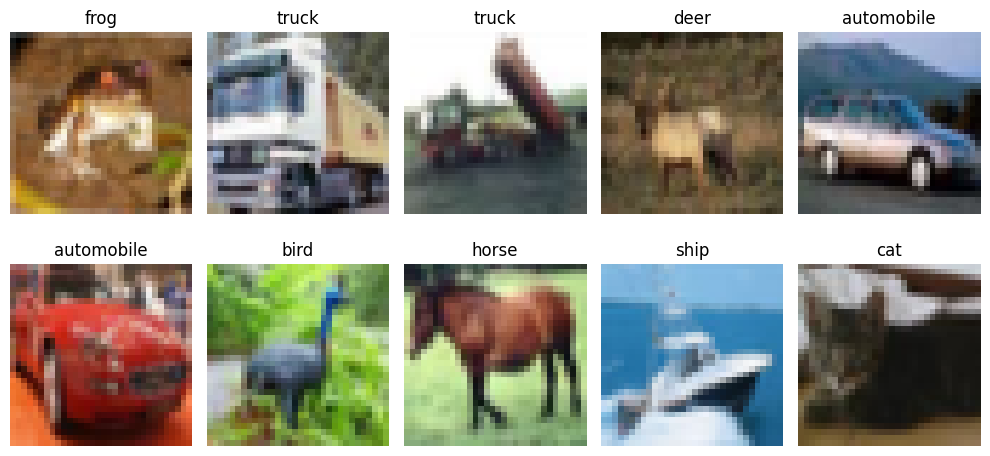

In [6]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Min Pixel:", x_train_norm.min())
print("Max Pixel:", x_train_norm.max())

Min Pixel: 0.0
Max Pixel: 1.0


In [8]:
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print(x_train_flat.shape)
print(x_test_flat.shape)

(50000, 3072)
(10000, 3072)


In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
ann_model = models.Sequential([

    layers.Dense(1024,
                 activation='relu',
                 input_shape=(3072,)),

    layers.Dropout(0.4),

    layers.Dense(512,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(256,
                 activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10,
                 activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.2044 - loss: 2.1108 - val_accuracy: 0.2877 - val_loss: 1.9651
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.2582 - loss: 1.9860 - val_accuracy: 0.3079 - val_loss: 1.9427
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.2670 - loss: 1.9512 - val_accuracy: 0.3005 - val_loss: 1.9283
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 70ms/step - accuracy: 0.2808 - loss: 1.9312 - val_accuracy: 0.3233 - val_loss: 1.8917
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.2889 - loss: 1.9117 - val_accuracy: 0.3040 - val_loss: 1.9020
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.2988 - loss: 1.8968 - val_accuracy: 0.3221 - val_loss: 1.8746
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.2968 - loss: 1.8885 - val_accuracy: 0.3363 - val_loss: 1.8679
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.3025 - loss: 1.8774 - 

In [12]:
ann_loss, ann_acc = ann_model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print("ANN Accuracy:", round(ann_acc*100,2), "%")

ANN Accuracy: 36.57 %


In [13]:
cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256,
                 activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 215ms/step - accuracy: 0.4292 - loss: 1.6239 - val_accuracy: 0.4249 - val_loss: 1.5448
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 213ms/step - accuracy: 0.5688 - loss: 1.2145 - val_accuracy: 0.5288 - val_loss: 1.4118
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.6381 - loss: 1.0356 - val_accuracy: 0.6558 - val_loss: 0.9633
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 218ms/step - accuracy: 0.6837 - loss: 0.9066 - val_accuracy: 0.7092 - val_loss: 0.8410
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 215ms/step - accuracy: 0.7188 - loss: 0.8052 - val_accuracy: 0.6519 - val_loss: 1.0830
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 215ms/step - accuracy: 0.7452 - loss: 0.7263 - val_accuracy: 0.7214 - val_loss: 0.8581
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.7730 - loss: 0.6542 - val_accuracy: 0.7165 - val_loss: 0.8382
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.7950 -

In [15]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("CNN Accuracy:", round(cnn_acc*100,2), "%")

CNN Accuracy: 71.05 %


In [16]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(
        factor=0.1
    ),

    layers.RandomZoom(
        height_factor=0.1,
        width_factor=0.1
    )

])

In [17]:
aug_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])

aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
aug_history = aug_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 232ms/step - accuracy: 0.4629 - loss: 1.4957 - val_accuracy: 0.5149 - val_loss: 1.3312
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 235ms/step - accuracy: 0.5208 - loss: 1.3441 - val_accuracy: 0.5563 - val_loss: 1.2341
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 230ms/step - accuracy: 0.5562 - loss: 1.2504 - val_accuracy: 0.5869 - val_loss: 1.1896


In [20]:
aug_loss, aug_acc = aug_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("Augmented CNN Accuracy:", round(aug_acc*100,2), "%")

Augmented CNN Accuracy: 51.0 %


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Accuracy":[
        ann_acc*100,
        cnn_acc*100,
        aug_acc*100
    ]
})

results

,Model,Accuracy
0,ANN,36.570001
1,CNN,71.050000
2,Augmented CNN,50.999999


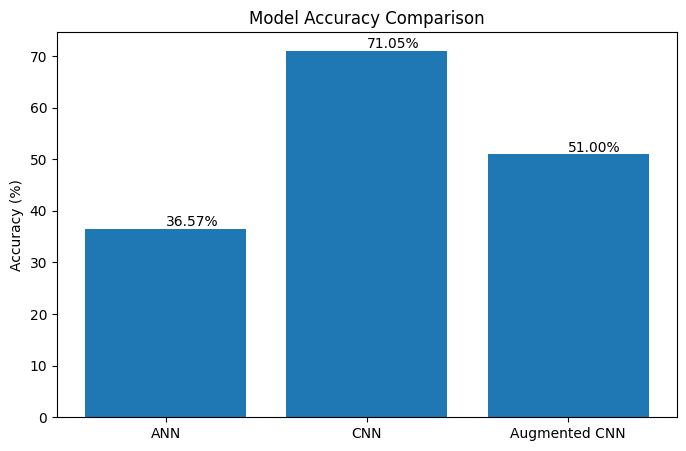

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for i,v in enumerate(results["Accuracy"]):
    plt.text(i,v+0.5,f"{v:.2f}%")

plt.show()

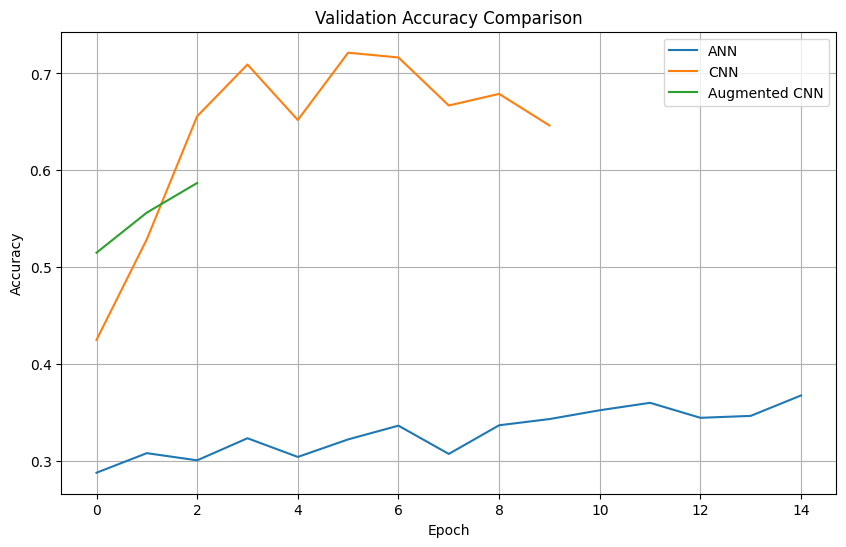

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.title(
    'Validation Accuracy Comparison'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

In [24]:
print("="*50)

print("ANN Accuracy        :", round(ann_acc*100,2), "%")
print("CNN Accuracy        :", round(cnn_acc*100,2), "%")
print("Augmented Accuracy  :", round(aug_acc*100,2), "%")

print("="*50)

ANN Accuracy        : 36.57 %
CNN Accuracy        : 71.05 %
Augmented Accuracy  : 51.0 %
